### SafetyAntVelocityGymnasium

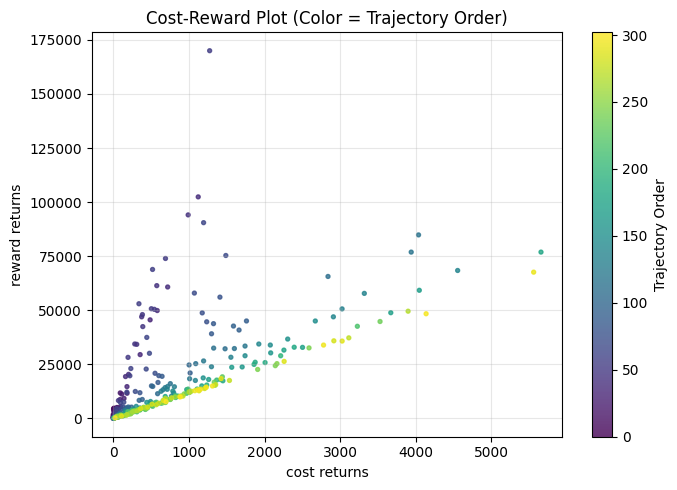

In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File("SafetyAntVelocityGymnasium-v1-250-2249.hdf5", "r") as f:
    rewards = np.asarray(f['rewards'][:])
    costs = np.asarray(f['costs'][:])
    dones = np.asarray(f['terminals'][:])  # Use 'terminals' as 'dones'

traj_reward_returns = []
traj_cost_returns = []
start = 0
for i, done in enumerate(dones):
    if done:
        traj_reward_returns.append(np.sum(rewards[start:i+1]))
        traj_cost_returns.append(np.sum(costs[start:i+1]))
        start = i + 1

traj_reward_returns = np.array(traj_reward_returns)
traj_cost_returns = np.array(traj_cost_returns)
traj_indices = np.arange(len(traj_reward_returns))  # Order of trajectories

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    traj_cost_returns, traj_reward_returns, 
    c=traj_indices, cmap='viridis', s=8, alpha=0.8
)
plt.xlabel('cost returns')
plt.ylabel('reward returns')
plt.title('Cost-Reward Plot (Color = Trajectory Order)')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Trajectory Order')
plt.tight_layout()
plt.show()

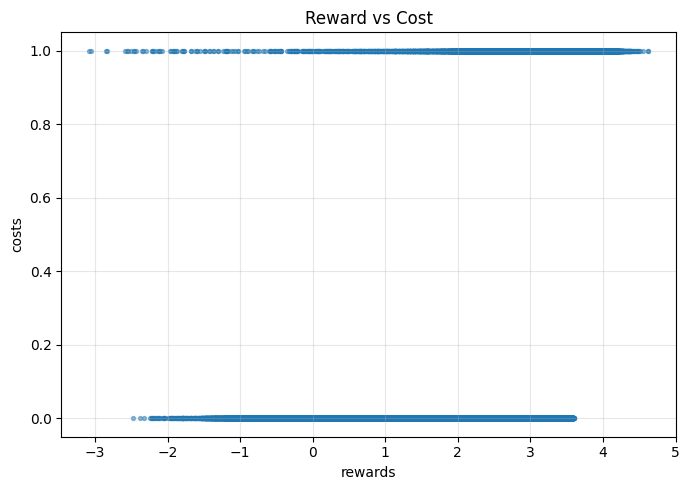

In [4]:
# SafetyAntVelocityGymnasium-v1-250-2249
# DSRL_data/datasets/SafetyAntVelocityGymnasium-v1-250-2249.hdf5

import matplotlib.pyplot as plt
import h5py
import numpy as np
with h5py.File("SafetyAntVelocityGymnasium-v1-250-2249.hdf5", "r") as f:
    keys = list(f.keys())

    reward_key = "reward" if "reward" in keys else ("rewards" if "rewards" in keys else next((k for k in keys if "reward" in k.lower()), None))
    cost_key = "cost" if "cost" in keys else ("costs" if "costs" in keys else next((k for k in keys if "cost" in k.lower()), None))

    if reward_key is None or cost_key is None:
        raise KeyError(f"Could not find reward/cost keys. Available keys: {keys}")

    rewards = np.asarray(f[reward_key][:]).reshape(-1)
    costs = np.asarray(f[cost_key][:]).reshape(-1)

n = min(len(rewards), len(costs))
rewards = rewards[:n]
costs = costs[:n]

plt.figure(figsize=(7, 5))
plt.scatter(rewards, costs, s=8, alpha=0.5)
plt.xlabel(reward_key)
plt.ylabel(cost_key)
plt.title("Reward vs Cost")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
zero_count = np.count_nonzero(costs == 0)
one_count = np.count_nonzero(costs == 1)

print(f"Number of cost=0 records: {zero_count}")
print(f"Number of cost=1 records: {one_count}")
total = len(costs)
pct_cost_0 = (zero_count / total) * 100
pct_cost_1 = (one_count / total) * 100

print(f"Percentage of cost=0: {pct_cost_0:.2f}%")
print(f"Percentage of cost=1: {pct_cost_1:.2f}%")

Number of cost=0 records: 1846584
Number of cost=1 records: 245680
Percentage of cost=0: 88.26%
Percentage of cost=1: 11.74%


### Mod 1 using Ant_v4 base class

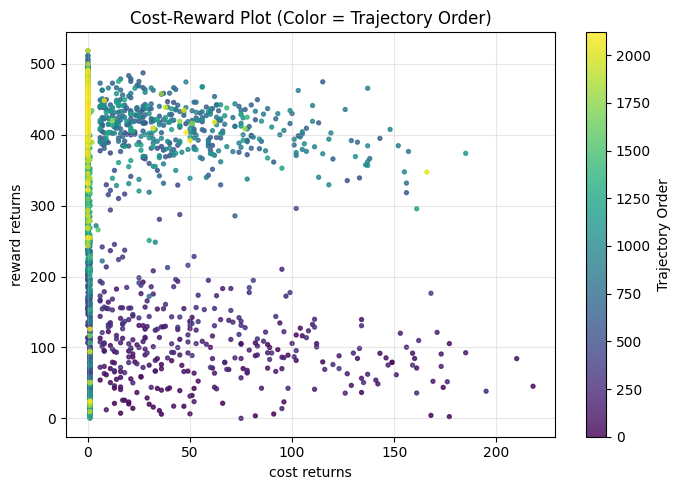

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File("trpol-75b3/dataset.hdf5", "r") as f:
    rewards = np.asarray(f['rewards'][:])
    costs = np.asarray(f['costs'][:])
    dones = np.asarray(f['terminals'][:])  # Use 'terminals' as 'dones'

traj_reward_returns = []
traj_cost_returns = []
start = 0
for i, done in enumerate(dones):
    if done:
        traj_reward_returns.append(np.sum(rewards[start:i+1]))
        traj_cost_returns.append(np.sum(costs[start:i+1]))
        start = i + 1

traj_reward_returns = np.array(traj_reward_returns)
traj_cost_returns = np.array(traj_cost_returns)
traj_indices = np.arange(len(traj_reward_returns))  # Order of trajectories

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    traj_cost_returns, traj_reward_returns, 
    c=traj_indices, cmap='viridis', s=8, alpha=0.8
)
plt.xlabel('cost returns')
plt.ylabel('reward returns')
plt.title('Cost-Reward Plot (Color = Trajectory Order)')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Trajectory Order')
plt.tight_layout()
plt.show()

In [2]:
import h5py
import os


file_path = os.path.expanduser('trpol-75b3/dataset.hdf5')
with h5py.File(file_path, 'r') as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")


actions: (567173, 8)
costs: (567173,)
next_observations: (567173, 29)
observations: (567173, 29)
rewards: (567173,)
terminals: (567173,)
timeouts: (567173,)


In [7]:
import h5py
import numpy as np

with h5py.File('trpol-75b3/dataset.hdf5', 'r') as f:
    for key in f.keys():
        data = f[key][:]
        if np.issubdtype(data.dtype, np.number):
            print(f"{key}: mean={np.mean(data):.3f}, min={np.min(data):.3f}, max={np.max(data):.3f}, shape={data.shape}")
        else:
            print(f"{key}: dtype={data.dtype}, shape={data.shape}")

actions: mean=0.022, min=-1.000, max=1.000, shape=(567173, 8)
costs: mean=0.075, min=0.000, max=1.000, shape=(567173,)
next_observations: mean=0.128, min=-18.412, max=18.008, shape=(567173, 29)
observations: mean=0.128, min=-18.412, max=18.008, shape=(567173, 29)
rewards: mean=1.174, min=-3.328, max=4.065, shape=(567173,)
terminals: dtype=bool, shape=(567173,)
timeouts: dtype=bool, shape=(567173,)


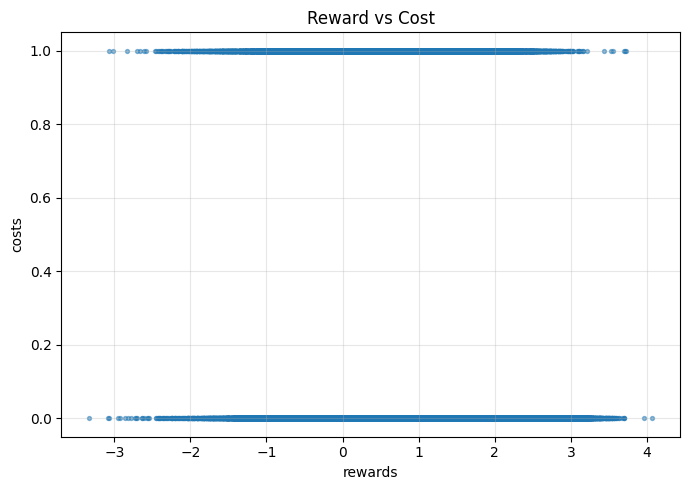

In [20]:
import matplotlib.pyplot as plt

with h5py.File("trpol-75b3/dataset.hdf5", "r") as f:
    keys = list(f.keys())

    reward_key = "reward" if "reward" in keys else ("rewards" if "rewards" in keys else next((k for k in keys if "reward" in k.lower()), None))
    cost_key = "cost" if "cost" in keys else ("costs" if "costs" in keys else next((k for k in keys if "cost" in k.lower()), None))

    if reward_key is None or cost_key is None:
        raise KeyError(f"Could not find reward/cost keys. Available keys: {keys}")

    rewards = np.asarray(f[reward_key][:]).reshape(-1)
    costs = np.asarray(f[cost_key][:]).reshape(-1)

n = min(len(rewards), len(costs))
rewards = rewards[:n]
costs = costs[:n]

plt.figure(figsize=(7, 5))
plt.scatter(rewards, costs, s=8, alpha=0.5)
plt.xlabel(reward_key)
plt.ylabel(cost_key)
plt.title("Reward vs Cost")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
zero_count = np.count_nonzero(costs == 0)
one_count = np.count_nonzero(costs == 1)

print(f"Number of cost=0 records: {zero_count}")
print(f"Number of cost=1 records: {one_count}")

Number of cost=0 records: 524803
Number of cost=1 records: 42370


In [22]:
total = len(costs)
pct_cost_0 = (zero_count / total) * 100
pct_cost_1 = (one_count / total) * 100

print(f"Percentage of cost=0: {pct_cost_0:.2f}%")
print(f"Percentage of cost=1: {pct_cost_1:.2f}%")

Percentage of cost=0: 92.53%
Percentage of cost=1: 7.47%


### Mod 2 using SafetyAntVelocityEnv base class

In [14]:
import h5py
import os


file_path = os.path.expanduser('trpol-2ed8/dataset.hdf5')
with h5py.File(file_path, 'r') as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")


actions: (450395, 8)
costs: (450395,)
next_observations: (450395, 29)
observations: (450395, 29)
rewards: (450395,)
terminals: (450395,)
timeouts: (450395,)


In [6]:
import h5py
import numpy as np

with h5py.File('trpol-2ed8/dataset.hdf5', 'r') as f:
    for key in f.keys():
        data = f[key][:]
        if np.issubdtype(data.dtype, np.number):
            print(f"{key}: mean={np.mean(data):.3f}, min={np.min(data):.3f}, max={np.max(data):.3f}, shape={data.shape}")
        else:
            print(f"{key}: dtype={data.dtype}, shape={data.shape}")

actions: mean=0.057, min=-1.000, max=1.000, shape=(450395, 8)
costs: mean=0.156, min=0.000, max=1.000, shape=(450395,)
next_observations: mean=0.140, min=-18.783, max=18.172, shape=(450395, 29)
observations: mean=0.140, min=-18.783, max=18.172, shape=(450395, 29)
rewards: mean=1.138, min=-3.172, max=3.662, shape=(450395,)
terminals: dtype=bool, shape=(450395,)
timeouts: dtype=bool, shape=(450395,)


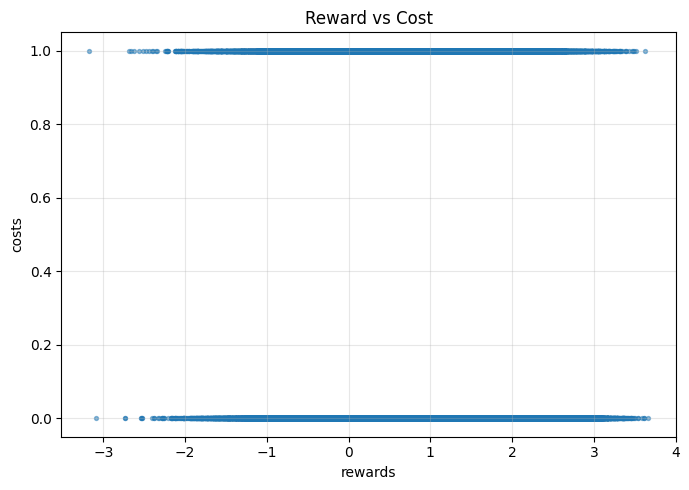

In [17]:
import matplotlib.pyplot as plt

with h5py.File("trpol-2ed8/dataset.hdf5", "r") as f:
    keys = list(f.keys())

    reward_key = "reward" if "reward" in keys else ("rewards" if "rewards" in keys else next((k for k in keys if "reward" in k.lower()), None))
    cost_key = "cost" if "cost" in keys else ("costs" if "costs" in keys else next((k for k in keys if "cost" in k.lower()), None))

    if reward_key is None or cost_key is None:
        raise KeyError(f"Could not find reward/cost keys. Available keys: {keys}")

    rewards = np.asarray(f[reward_key][:]).reshape(-1)
    costs = np.asarray(f[cost_key][:]).reshape(-1)

n = min(len(rewards), len(costs))
rewards = rewards[:n]
costs = costs[:n]

plt.figure(figsize=(7, 5))
plt.scatter(rewards, costs, s=8, alpha=0.5)
plt.xlabel(reward_key)
plt.ylabel(cost_key)
plt.title("Reward vs Cost")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
zero_count = np.count_nonzero(costs == 0)
one_count = np.count_nonzero(costs == 1)

print(f"Number of cost=0 records: {zero_count}")
print(f"Number of cost=1 records: {one_count}")

Number of cost=0 records: 379999
Number of cost=1 records: 70396


In [19]:
total = len(costs)
pct_cost_0 = (zero_count / total) * 100
pct_cost_1 = (one_count / total) * 100

print(f"Percentage of cost=0: {pct_cost_0:.2f}%")
print(f"Percentage of cost=1: {pct_cost_1:.2f}%")

Percentage of cost=0: 84.37%
Percentage of cost=1: 15.63%


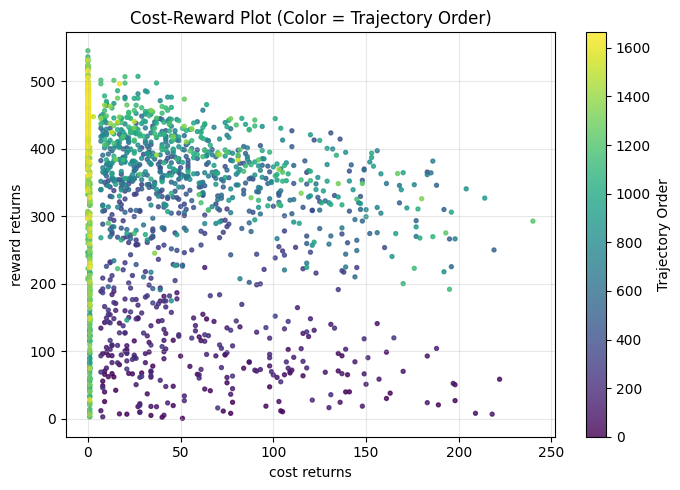

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File("trpol-2ed8/dataset.hdf5", "r") as f:
    rewards = np.asarray(f['rewards'][:])
    costs = np.asarray(f['costs'][:])
    dones = np.asarray(f['terminals'][:])  # Use 'terminals' as 'dones'

traj_reward_returns = []
traj_cost_returns = []
start = 0
for i, done in enumerate(dones):
    if done:
        traj_reward_returns.append(np.sum(rewards[start:i+1]))
        traj_cost_returns.append(np.sum(costs[start:i+1]))
        start = i + 1

traj_reward_returns = np.array(traj_reward_returns)
traj_cost_returns = np.array(traj_cost_returns)
traj_indices = np.arange(len(traj_reward_returns))  # Order of trajectories

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    traj_cost_returns, traj_reward_returns, 
    c=traj_indices, cmap='viridis', s=8, alpha=0.8
)
plt.xlabel('cost returns')
plt.ylabel('reward returns')
plt.title('Cost-Reward Plot (Color = Trajectory Order)')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Trajectory Order')
plt.tight_layout()
plt.show()